# 01 — Kerr Geodesics

This notebook covers the `fewtrax.utils.geodesic` module, which provides the mathematical foundations for the entire waveform pipeline.

**Topics:**
- Orbital energy $E(a, p, e)$ and angular momentum $L_z(a, p, e)$
- The separatrix $p_{\rm sep}(a, e)$ — the innermost stable orbit boundary
- Boyer–Lindquist fundamental frequencies $\Omega_\phi,\, \Omega_\theta,\, \Omega_r$
- JAX-differentiability of these quantities

---

## Background

An EMRI consists of a stellar-mass compact object (the *secondary*, mass $\mu \sim 10 M_\odot$) orbiting a massive Kerr black hole (the *primary*, mass $M \sim 10^6 M_\odot$). Over many orbital periods the secondary slowly inspirals due to gravitational-wave emission.

For **equatorial eccentric orbits** in Boyer–Lindquist coordinates, the orbit is characterised by:
- $a \in [-1, 1]$: dimensionless BH spin ($a>0$ prograde, $a<0$ retrograde)
- $p$: semi-latus rectum (orbit scale, in units of $M$)
- $e \in [0, 1)$: eccentricity

The radial turning points are $r_{1,2} = p/(1 \mp e)$ (apocenter, pericenter).

Each orbit has two conserved quantities: specific energy $E$ and specific $z$-angular momentum $L_z$, given by closed-form expressions from Schmidt (2002).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)  # use 64-bit floats throughout

# Set the path to the FEW data directory.
# This notebook only uses geodesic utilities, which do not require data files.
# DATA_DIR is shown here for completeness; later notebooks will use it.
from dotenv import load_dotenv
load_dotenv()
DATA_DIR = os.getenv("FEW_DATA_DIR")
print(f"FEW_DATA_DIR = {DATA_DIR}")

FEW_DATA_DIR = /Users/bertd/Documents/PhD/LISA/Codes/FastEMRIWaveforms/src/few/data


In [2]:
# Import the geodesic utilities
from fewtrax.utils.geodesic import (
    kerr_geo_energy_equatorial,
    kerr_geo_angular_momentum_equatorial,
    get_separatrix,
    get_fundamental_frequencies,
)

# Example parameters
a   = 0.7    # BH spin
p   = 10.0   # semi-latus rectum [M]
e   = 0.4    # eccentricity
x   = 1.0    # prograde (x = +1)

E  = kerr_geo_energy_equatorial(a, p, e, x)
L  = kerr_geo_angular_momentum_equatorial(a, p, e, x, E)

print(f"E  = {float(E):.8f}  (dimensionless specific energy)")
print(f"Lz = {float(L):.8f}  (specific angular momentum [M])")

E  = 0.96011768  (dimensionless specific energy)
Lz = 3.54553556  (specific angular momentum [M])


## 1.1  Orbital energy as a function of $p$ and $e$

For a Kerr geodesic the energy $E(a, p, e, x)$ is given by (Schmidt 2002, Eq. 28–32 specialised to equatorial)

$$
E = \sqrt{1 - \frac{(1-e^2)}{p}\left(1 + \frac{N}{D}\right)}
$$

where $N$ and $D$ are polynomials in $(a, p, e)$.  For Schwarzschild ($a=0$) this reduces to the familiar
$E = \sqrt{1 - \frac{(1-e^2)(p-2-2e)(p-2+2e)}{p[(p-2)^2 - 4e^2]}}.$

Below we visualise $E$ as a function of $p$ for several eccentricities.

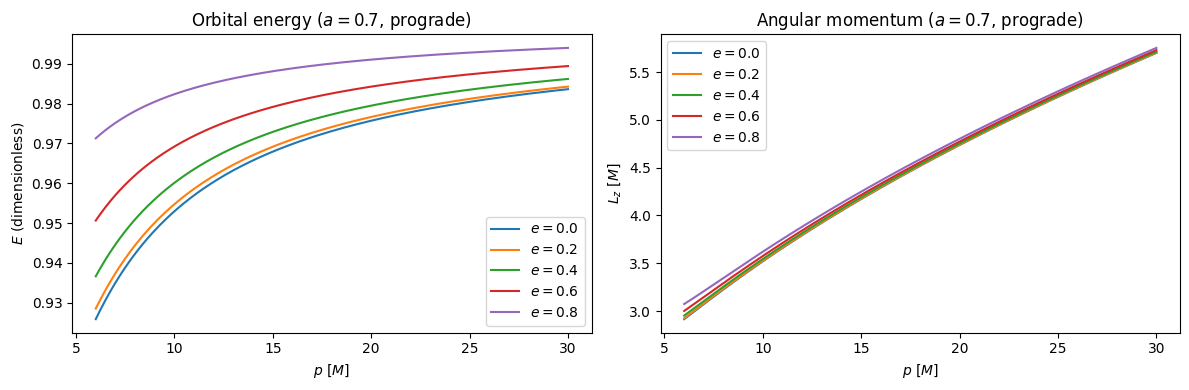

In [3]:
a = 0.7
p_grid = np.linspace(6, 30, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for e_val, color in zip([0.0, 0.2, 0.4, 0.6, 0.8], ["C0", "C1", "C2", "C3", "C4"]):
    E_arr = np.array([float(kerr_geo_energy_equatorial(a, p, e_val, 1.0)) for p in p_grid])
    L_arr = np.array([
        float(kerr_geo_angular_momentum_equatorial(
            a, p, e_val, 1.0,
            kerr_geo_energy_equatorial(a, p, e_val, 1.0)
        )) for p in p_grid
    ])
    axes[0].plot(p_grid, E_arr, color=color, label=f"$e={e_val}$")
    axes[1].plot(p_grid, L_arr, color=color, label=f"$e={e_val}$")

axes[0].set_xlabel("$p$ [$M$]")
axes[0].set_ylabel("$E$ (dimensionless)")
axes[0].set_title(f"Orbital energy ($a={a}$, prograde)")
axes[0].legend()

axes[1].set_xlabel("$p$ [$M$]")
axes[1].set_ylabel("$L_z$ [$M$]")
axes[1].set_title(f"Angular momentum ($a={a}$, prograde)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 1.2  The Separatrix

The **separatrix** $p_{\rm sep}(a, e)$ is the critical semi-latus rectum below which the orbit plunges into the black hole — it is the innermost stable eccentric orbit for given $(a, e)$.

For Schwarzschild ($a = 0$): $p_{\rm sep} = 6 + 2e$.  
For Kerr prograde, the separatrix is smaller (the ISCO shrinks as $a \to 1$).

Mathematically, $p_{\rm sep}$ is the root of a degree-4 polynomial in $p$ (Glampedakis & Kennefick 2002).  In fewtrax it is found via 50-iteration bisection using `jax.lax.fori_loop`, which preserves JAX differentiability.

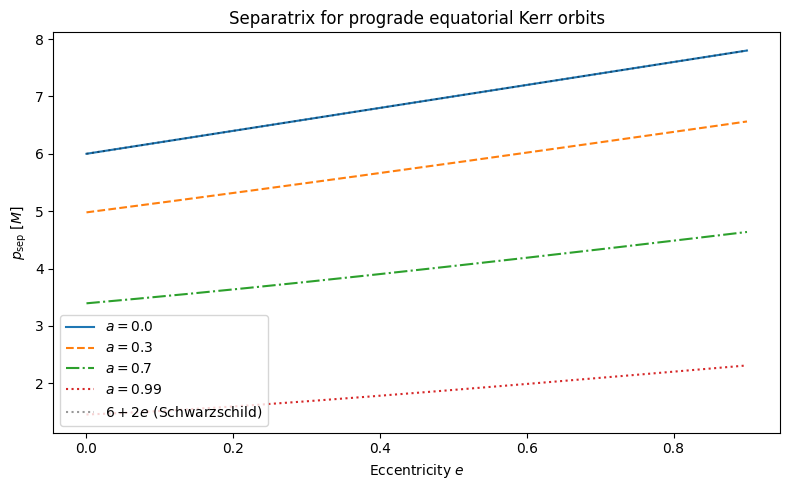

In [4]:
e_grid = np.linspace(0.0, 0.9, 200)

fig, ax = plt.subplots(figsize=(8, 5))

for a_val, style in zip([0.0, 0.3, 0.7, 0.99], ["-", "--", "-.", ":"]):
    p_sep_arr = np.array([float(get_separatrix(a_val, e, 1.0)) for e in e_grid])
    ax.plot(e_grid, p_sep_arr, style, label=f"$a={a_val}$")

# Schwarzschild analytical reference
ax.plot(e_grid, 6 + 2*e_grid, "k:", alpha=0.4, label="$6+2e$ (Schwarzschild)")

ax.set_xlabel("Eccentricity $e$")
ax.set_ylabel("$p_{\\rm sep}$ [$M$]")
ax.set_title("Separatrix for prograde equatorial Kerr orbits")
ax.legend()
plt.tight_layout()
plt.show()

## 1.3  Fundamental Frequencies

Kerr geodesics are tri-periodic: the radial, polar and azimuthal motions have incommensurate periods in general.  The three **Boyer–Lindquist fundamental frequencies** are:

$$
\Omega_\phi = \frac{2\pi}{T_\phi}, \quad \Omega_\theta = \frac{2\pi}{T_\theta}, \quad \Omega_r = \frac{2\pi}{T_r}
$$

expressed in units of $M^{-1}$ (geometric time).  These control the phase accumulation in the waveform:

$$
\Phi_{mkn}(t) = m\,\Phi_\phi(t) + k\,\Phi_\theta(t) + n\,\Phi_r(t)
$$

For equatorial orbits $\Omega_\theta = \Omega_\phi$ (precession of the orbital plane is absent), so only $\Omega_\phi$ and $\Omega_r$ are independent.

The frequencies involve complete elliptic integrals $K(m)$, $E(m)$, $\Pi(n, k)$, which are computed via 64-point Gauss–Legendre quadrature in `geodesic.py` (JAX's `jax.scipy.special` does not provide $\Pi$).

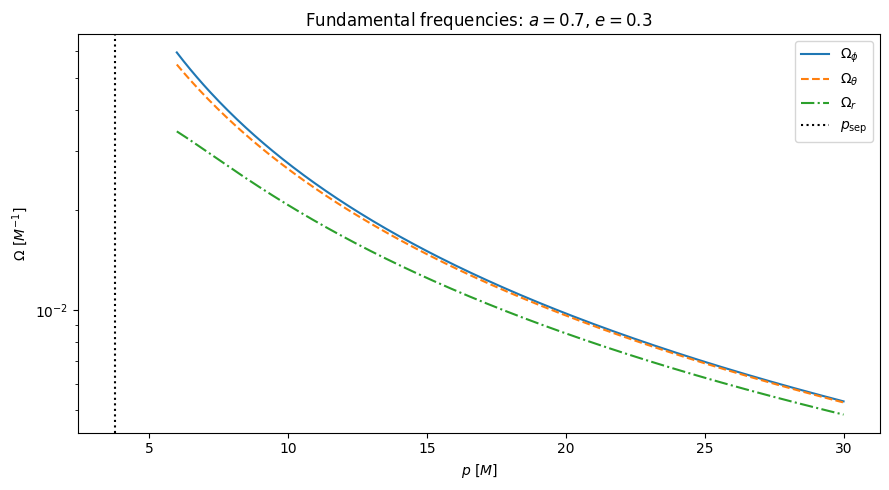

In [5]:
a = 0.7
p_grid = np.linspace(6, 30, 300)
e = 0.3

Om_phi_arr   = []
Om_theta_arr = []
Om_r_arr     = []

for p_val in p_grid:
    Ophi, Oth, Or = get_fundamental_frequencies(a, p_val, e, 1.0)
    Om_phi_arr.append(float(Ophi))
    Om_theta_arr.append(float(Oth))
    Om_r_arr.append(float(Or))

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(p_grid, Om_phi_arr,   label=r"$\Omega_\phi$")
ax.semilogy(p_grid, Om_theta_arr, "--", label=r"$\Omega_\theta$")
ax.semilogy(p_grid, Om_r_arr,     "-.", label=r"$\Omega_r$")
ax.axvline(float(get_separatrix(a, e, 1.0)), color="k", linestyle=":", label="$p_{\\rm sep}$")
ax.set_xlabel("$p$ [$M$]")
ax.set_ylabel(r"$\Omega$ [$M^{-1}$]")
ax.set_title(f"Fundamental frequencies: $a={a}$, $e={e}$")
ax.legend()
plt.tight_layout()
plt.show()

Note that $\Omega_\theta = \Omega_\phi$ for equatorial orbits, and all frequencies diverge as $p \to p_{\rm sep}$. At the separatrix the framework becomes unstabe and is cut off. 

## 1.4  JAX Differentiability

All geodesic functions are JAX-differentiable.  This enables gradient-based parameter estimation.  Let's verify by computing $\partial E / \partial p$ and $\partial \Omega_\phi / \partial p$ analytically via `jax.grad`:

In [6]:
a, e, x = 0.7, 0.4, 1.0

# Scalar gradient of energy w.r.t. p
dEdp_fn  = jax.grad(lambda p: kerr_geo_energy_equatorial(a, p, e, x))
dOmpdp_fn = jax.grad(lambda p: get_fundamental_frequencies(a, p, e, x)[0])

p_vals = [8.0, 10.0, 15.0, 20.0]
print(f"{'p':>6}  {'dE/dp':>12}  {'dΩφ/dp':>14}")
print("-" * 38)
for pv in p_vals:
    pj = jnp.float64(pv)
    print(f"{pv:6.1f}  {float(dEdp_fn(pj)):12.6e}  {float(dOmpdp_fn(pj)):14.6e}")

     p         dE/dp          dΩφ/dp
--------------------------------------
   8.0  5.622196e-03   -6.769769e-03
  10.0  3.754099e-03   -3.820697e-03
  15.0  1.743198e-03   -1.366633e-03
  20.0  9.986870e-04   -6.613642e-04


Finite-difference check to verify the analytic gradients:

In [7]:
p0 = jnp.float64(10.0)
h  = jnp.float64(1e-5)

dEdp_fd = (kerr_geo_energy_equatorial(a, p0+h, e, x)
         - kerr_geo_energy_equatorial(a, p0-h, e, x)) / (2*h)
dEdp_ad = dEdp_fn(p0)

print(f"dE/dp  (finite difference): {float(dEdp_fd):.8e}")
print(f"dE/dp  (JAX autodiff)     : {float(dEdp_ad):.8e}")
print(f"Relative error: {abs(float(dEdp_fd)-float(dEdp_ad))/abs(float(dEdp_ad)):.2e}")

dE/dp  (finite difference): 3.75409922e-03
dE/dp  (JAX autodiff)     : 3.75409922e-03
Relative error: 2.41e-10


## 1.5  Retrograde vs. Prograde Orbits

For retrograde orbits ($x = -1$, or equivalently $a < 0$), the separatrix is larger — retrograde orbits are less tightly bound — and the angular momentum $L_z < 0$.

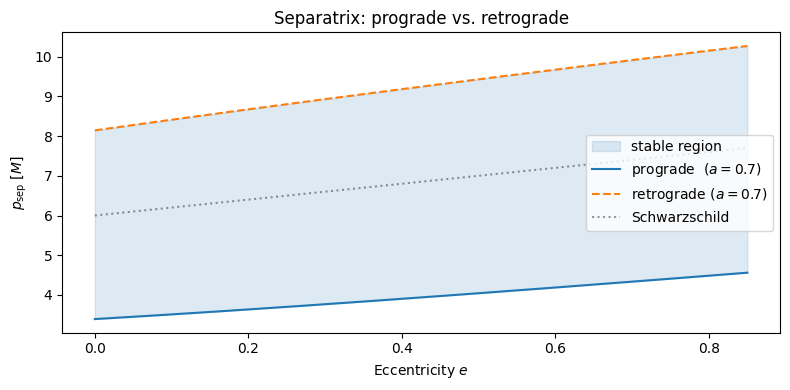

In [8]:
e_grid = np.linspace(0.0, 0.85, 150)
a = 0.7

p_sep_pro  = np.array([float(get_separatrix( a, e, +1.0)) for e in e_grid])
p_sep_retro = np.array([float(get_separatrix(a, e, -1.0)) for e in e_grid])

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(e_grid, p_sep_pro, p_sep_retro, alpha=0.15, color="C0", label="stable region")
ax.plot(e_grid, p_sep_pro,   label=f"prograde  ($a={a}$)")
ax.plot(e_grid, p_sep_retro, "--", label=f"retrograde ($a={a}$)")
ax.plot(e_grid, 6+2*e_grid, "k:", alpha=0.4, label="Schwarzschild")
ax.set_xlabel("Eccentricity $e$")
ax.set_ylabel("$p_{\\rm sep}$ [$M$]")
ax.legend()
ax.set_title("Separatrix: prograde vs. retrograde")
plt.tight_layout()
plt.show()

## Summary

| Function | Source | Notes |
|---|---|---|
| `kerr_geo_energy_equatorial(a, p, e, x)` | Schmidt (2002) | Closed-form; JIT + differentiable |
| `kerr_geo_angular_momentum_equatorial(a, p, e, x, E)` | Schmidt (2002) | Needs $E$ as input |
| `get_separatrix(a, e, x)` | Glampedakis & Kennefick (2002) | `fori_loop` bisection; reverse-mode AD safe |
| `get_fundamental_frequencies(a, p, e, x)` | Schmidt (2002) | Uses 64-pt GL quadrature for $\Pi(n,k)$ |

**Next:** [02_emri_trajectory.ipynb](02_emri_trajectory.ipynb) — how these geodesic quantities drive the adiabatic inspiral ODE.